# Exercise 10 — Contagion Dynamics on MovieLens

The goal is to move from static structure to a simple dynamic model, using a contagion process on the user-movie bipartite graph.

## Goal
Simulate a simple contagion model on the MovieLens bipartite network to understand how network structure and seed selection affect spread. We compare a random seed scenario with a high-degree movie seed scenario.

## Setup
Import the packages and load the MovieLens `ml-latest-small` dataset used in previous exercises.

In [1]:
import sys
print(sys.executable)

/workspaces/netsci/.venv/bin/python


In [2]:
import sys
!{sys.executable} -m pip install pandas networkx matplotlib numpy

  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## Load Data and Build Graph
We build the same bipartite user-movie graph as in earlier MovieLens exercises. Users are one node type, movies are the other, and ratings create edges.

In [4]:
ratings = pd.read_csv('../data/movielense/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/movielense/ml-latest-small/movies.csv')

ratings['user_node'] = ratings['userId'].astype(str).radd('user_')
ratings['movie_node'] = ratings['movieId'].astype(str).radd('movie_')
movies['movie_node'] = movies['movieId'].astype(str).radd('movie_')

G = nx.Graph()
G.add_nodes_from(ratings['user_node'].unique(), bipartite=0)
G.add_nodes_from(ratings['movie_node'].unique(), bipartite=1)
G.add_edges_from(zip(ratings['user_node'], ratings['movie_node']))

print(f'Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')

Graph built with 10334 nodes and 100836 edges.


## Dynamic Model: Simple Contagion
We use a threshold contagion model. Each node can be in one of two states: `inactive` or `active`. An inactive node becomes active if at least one neighbor is active and a random adoption draw succeeds. This process is appropriate for a recommendation system where exposure to a popular item or peer can lead to adoption.

### Model details
- State: `0` = inactive, `1` = active.
- Transition rule: At each step, each inactive node with at least one active neighbor becomes active with probability `p`.
- Timing: Discrete synchronous updates.
- Seed scenarios: `random seed` vs. `high-degree movie seed`.

In [5]:
def simulate_contagion(G, initial_active, p=0.2, max_steps=20):
    state = {node: 1 if node in initial_active else 0 for node in G.nodes()}
    active_counts = [sum(state.values())]
    active_fraction = [active_counts[0] / G.number_of_nodes()]

    for step in range(max_steps):
        new_state = state.copy()
        for node in G.nodes():
            if state[node] == 0:
                neighbors = list(G.neighbors(node))
                if any(state[n] == 1 for n in neighbors):
                    if random.random() < p:
                        new_state[node] = 1
        state = new_state
        active_counts.append(sum(state.values()))
        active_fraction.append(active_counts[-1] / G.number_of_nodes())
        if active_counts[-1] == active_counts[-2]:
            break

    return active_fraction

## Seed Selection
We compare two seed sets:
1. `random_seed`: 5 randomly chosen nodes.
2. `high_degree_movie_seed`: the top 5 movies by ratings.

The high-degree movie seed is justified because important nodes from earlier exercises are the blockbuster movies that connect many users. The random seed serves as a baseline for spread without structural advantage.

In [6]:
movie_nodes = ratings['movie_node'].unique()
user_nodes = ratings['user_node'].unique()

random_seed = random.sample(list(G.nodes()), 5)
top_movie_nodes = sorted(movie_nodes, key=lambda n: G.degree(n), reverse=True)[:5]

print('Random seed nodes:', random_seed)
print('Top movie seed nodes:', top_movie_nodes)

Random seed nodes: ['movie_187595', 'movie_69118', 'movie_1198', 'movie_25940', 'movie_31114']
Top movie seed nodes: ['movie_356', 'movie_318', 'movie_296', 'movie_593', 'movie_2571']


## Simulation Runs
Run the contagion process for both seed scenarios and compare low and high adoption probability values.

In [7]:
p_values = [0.1, 0.4]
results = {}

for p in p_values:
    results[f'random_p_{p}'] = simulate_contagion(G, random_seed, p=p, max_steps=20)
    results[f'top_movies_p_{p}'] = simulate_contagion(G, top_movie_nodes, p=p, max_steps=20)

results

{'random_p_0.1': [0.00048383975227404683,
  0.0022256628604606153,
  0.02467582736597639,
  0.06338300754790013,
  0.10625120959938068,
  0.16402167602090187,
  0.2160828333655893,
  0.26795045480936713,
  0.31846332494677765,
  0.3681052835300948,
  0.41155409328430426,
  0.45277724017805304,
  0.49022643700406426,
  0.5322237275014515,
  0.561931488291078,
  0.5918327849816141,
  0.6228952970776079,
  0.6528933617185988,
  0.6811496032514032,
  0.707083413973292,
  0.7310818656860848],
 'top_movies_p_0.1': [0.00048383975227404683,
  0.005322237275014515,
  0.0444164892587575,
  0.09289723243661699,
  0.1425391910199342,
  0.19150377395006773,
  0.2459841300561254,
  0.28933617185988003,
  0.3354944842268241,
  0.3856202825624153,
  0.42926262821753436,
  0.4721308302690149,
  0.5093864911941165,
  0.5518676214437778,
  0.593381072188891,
  0.634507451132185,
  0.6672150183859106,
  0.696922779175537,
  0.7214050706406039,
  0.7467582736597639,
  0.7687245984130057],
 'random_p_0.4': 

## Results Visualization
Plot the fraction of active nodes over time for each scenario.

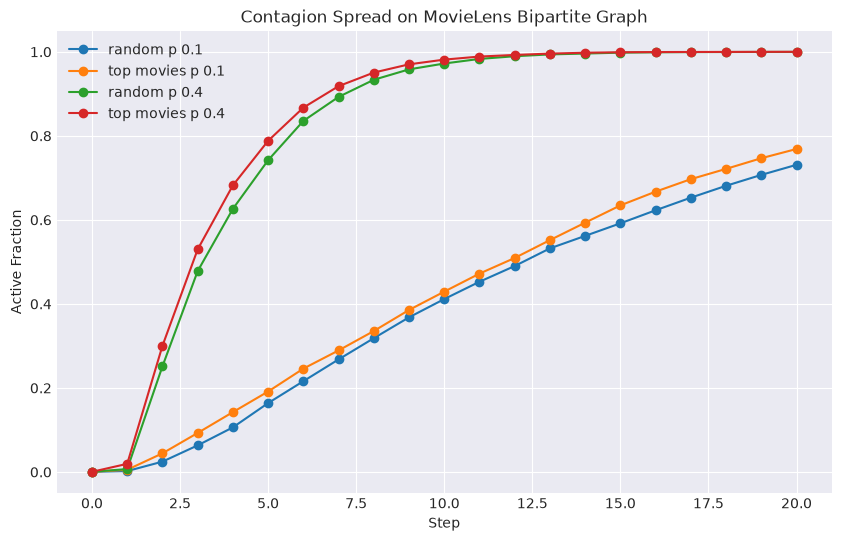

In [8]:
plt.figure(figsize=(10, 6))
for label, series in results.items():
    plt.plot(series, marker='o', label=label.replace('_', ' '))

plt.xlabel('Step')
plt.ylabel('Active Fraction')
plt.title('Contagion Spread on MovieLens Bipartite Graph')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation
The high-degree movie seed should generally produce faster and larger spread because these movies connect to many users. Random seeds are less likely to reach the network core quickly, especially when adoption probability is low.

### Expected structural effects
- Blockbuster movies act as structural hubs, exposing many users immediately.
- Random seeds may start in peripheral regions and require more steps to reach broad adoption.
- Higher probability (`p=0.4`) amplifies the structural advantages of the hub-based seed, while lower probability (`p=0.1`) can suppress spread and make the difference between scenarios more pronounced.

## Conclusion
This simulation shows how a network's hub structure changes dynamic outcomes. In MovieLens, major movies are important spreaders because they connect to many users, so contagion seeded from those movies can infect a much larger portion of the network faster than random seeds.

A practical lesson for recommendation systems is that promoting well-connected movies or users can accelerate adoption, while random promotion has a weaker and slower effect.